# 4 EV Charging under Stochastic Demand — Reinforcement Learning

An EV arrives home with a random state of charge and must be charged over 2 hours to cover an unknown next-day demand. Charging faster is disproportionately more expensive; an empty-enough battery at departure incurs a large penalty. We model this as an MDP, solve it exactly with dynamic programming as a benchmark, and learn it with **Monte Carlo** and **Q-learning**.

### Data Requirements
None

In [2]:
# # # Setup # # #
import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from scipy.stats import norm

# Switch to the project root so paths are robust
_here = Path.cwd()
for _p in [_here, *_here.parents]:
    if (_p / "pyproject.toml").exists():
        os.chdir(_p)
        break
print("Working directory:", os.getcwd())

np.random.seed(42)

Working directory: /Users/hendrik/Coding/Master/AAA/AAA_TA_2026


## 1. The problem as an MDP

- **State** $s_t = (\text{SOC}_t,\ t)$ — battery charge (kWh) and the step index $t \in \{0,\dots,7\}$.
  The demand is **not** part of the state (it is unknown until departure).
- **Actions** $a$: charge at `zero` / `low` / `medium` / `high` power.
- **Dynamics (deterministic):** $\text{SOC}_{t+1} = \text{SOC}_t + p_a$.
- **Cost of one step:** $cost(p) = \alpha \cdot X^{p/p_{\max}} \cdot p\,\Delta t$
  — higher charging power costs disproportionately more per kWh.
- **Random demand:** at departure a demand $D \sim \mathcal{N}(\mu, \sigma)$ kWh is drawn. The reward gets
  a **large penalty** if the battery falls short: $\text{reward} \mathrel{-}= \text{PENALTY}$ when $\text{SOC} < D$.

The transition diagram below shows one episode: the charging loop (state $\to$ chosen power $\to$ next state) repeats $N = 8$ times with deterministic transitions, and only the departure step branches — on the drawn demand.

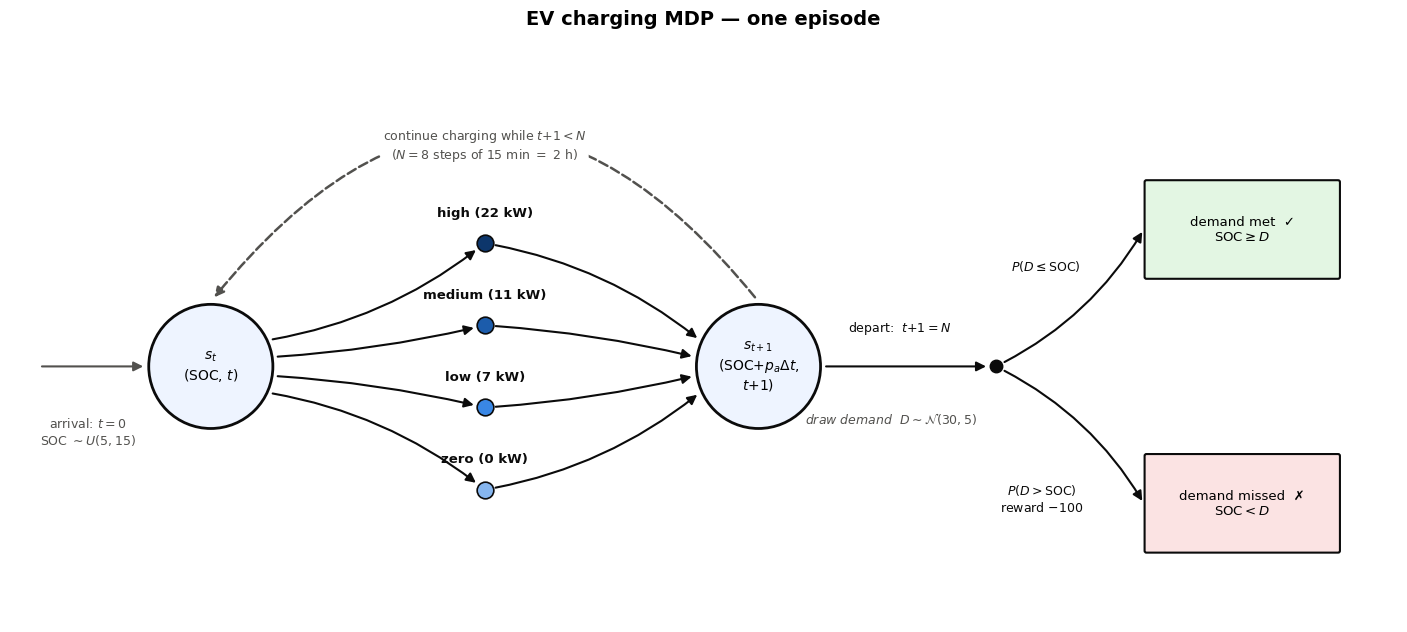

In [ ]:
#| label: fig-rl-mdp
#| fig-cap: "Transition structure of the EV-charging MDP"

# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# MDP transition diagram                  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from matplotlib.patches import Circle, FancyArrowPatch, FancyBboxPatch

INK, MUTED = "#0b0b0b", "#52514e"
STATE_FC, STATE_R = "#eef4ff", 0.68
# ordinal blues, same as the policy colormap in section 7 (zero -> high)
ACTION_COLORS = {"zero": "#86b6ef", "low": "#3987e5", "medium": "#1c5cab", "high": "#0d366b"}


def state_node(ax, xy, label):
    ax.add_patch(Circle(xy, STATE_R, fc=STATE_FC, ec=INK, lw=2, zorder=3))
    ax.text(*xy, label, ha="center", va="center", fontsize=10, zorder=4)
    return np.array(xy)


def action_dot(ax, xy, color, label):
    ax.plot(*xy, "o", color=color, mec=INK, mew=1.2, ms=12, zorder=3)
    ax.text(xy[0], xy[1] + 0.26, label, ha="center", va="bottom",
            fontsize=9.5, fontweight="bold", color=INK, zorder=4)


def on_circle(center, toward, r=STATE_R + 0.03):
    """Point on the circle around `center`, in the direction of `toward`."""
    d = np.asarray(toward, float) - np.asarray(center, float)
    return tuple(np.asarray(center, float) + r * d / np.linalg.norm(d))


def edge(ax, a, b, rad=0.0, label=None, lxy=None, color=INK, ls="-", lw=1.5,
         shrinkA=2, shrinkB=2):
    ax.add_patch(FancyArrowPatch(
        a, b, connectionstyle=f"arc3,rad={rad}", arrowstyle="-|>",
        mutation_scale=14, lw=lw, color=color, ls=ls,
        shrinkA=shrinkA, shrinkB=shrinkB, zorder=2))
    if label and lxy:
        ax.text(*lxy, label, fontsize=9, ha="center", va="center", color=color, zorder=5,
                bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none"))


def terminal_box(ax, xy, label, fc):
    ax.add_patch(FancyBboxPatch((xy[0] - 1.05, xy[1] - 0.52), 2.1, 1.04,
                 boxstyle="round,pad=0.02", fc=fc, ec=INK, lw=1.5, zorder=3))
    ax.text(*xy, label, ha="center", va="center", fontsize=9.5, zorder=4)


fig, ax = plt.subplots(figsize=(15, 6.4))

# charging loop: state -> action (agent's choice) -> next state, then loop back
s_t  = state_node(ax, (2.2, 3.4), "$s_t$\n(SOC, $t$)")
s_t1 = state_node(ax, (8.2, 3.4), "$s_{t+1}$\n(SOC$+p_a\\Delta t$,\n$t{+}1$)")

DOTS = [("high (22 kW)", 4.75), ("medium (11 kW)", 3.85), ("low (7 kW)", 2.95), ("zero (0 kW)", 2.05)]
for name, y in DOTS:
    dot = (5.2, y)
    action_dot(ax, dot, ACTION_COLORS[name.split()[0]], name)
    bend = 0.13 * (y - 3.4) / 1.35
    edge(ax, on_circle(s_t, dot), dot, rad=bend, shrinkB=8)
    edge(ax, dot, on_circle(s_t1, dot), rad=-bend, shrinkA=8)

edge(ax, (8.2, 4.11), (2.2, 4.11), rad=0.62, ls="--", color=MUTED, lw=1.8,
     shrinkA=4, shrinkB=4,
     label="continue charging while $t{+}1 < N$\n($N = 8$ steps of 15 min $=$ 2 h)", lxy=(5.2, 5.82))

# arrival: the episode enters the loop with a random start SOC
edge(ax, (0.35, 3.4), (2.2 - STATE_R - 0.03, 3.4), color=MUTED, shrinkA=0)
ax.text(0.85, 2.85, "arrival: $t{=}0$\nSOC $\\sim U(5, 15)$", ha="center", va="top",
        fontsize=9, color=MUTED)

# departure: chance node draws the demand and decides feasibility
chance = (10.8, 3.4)
edge(ax, (8.2 + STATE_R + 0.03, 3.4), chance, shrinkB=7,
     label="depart:  $t{+}1 = N$", lxy=(9.75, 3.82))
ax.plot(*chance, "o", color=INK, ms=9, zorder=3)
ax.text(10.6, 2.83, "draw demand  $D \\sim \\mathcal{N}(30, 5)$", ha="right", va="center",
        fontsize=9, style="italic", color=MUTED)

terminal_box(ax, (13.5, 4.9), "demand met  ✓\n$\\mathrm{SOC} \\geq D$", "#e3f6e3")
terminal_box(ax, (13.5, 1.9), "demand missed  ✗\n$\\mathrm{SOC} < D$", "#fbe3e3")
edge(ax, chance, (12.42, 4.9), rad=0.15, shrinkA=7,
     label="$P(D \\leq \\mathrm{SOC})$", lxy=(11.35, 4.5))
edge(ax, chance, (12.42, 1.9), rad=-0.15, shrinkA=7,
     label="$P(D > \\mathrm{SOC})$\nreward $-100$", lxy=(11.3, 1.95))

# cosmetics
ax.set_xlim(0, 15.2)
ax.set_ylim(0.6, 6.7)
ax.set_aspect("equal")
ax.axis("off")
fig.suptitle("EV charging MDP — one episode", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 2. Configuration & cost function

In [ ]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Configuration                           #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #


N_STEPS  = 8            # 8 x 15-min steps = 2 h at home (2pm -> 4pm)
DELTA_T  = 0.25         # hours per step
SOC_INIT_MIN = 5.0      # kWh in the battery at arrival (lower bound)
SOC_INIT_MAX = 15.0     # kWh in the battery at arrival (upper bound)
CAPACITY = 60.0         # kWh battery capacity

DEMAND_MU    = 30.0     # kWh, mean next-day demand
DEMAND_SIGMA = 5.0      # kWh, demand std-dev 

P_MAX = 22              # kW, fastest charger
X = 5.0                 # per-kWh price multiplier at full power vs. slower charging
CHARGING_LEVELS = {"zero": 0, "low": 7, "medium": 11, "high": 22}  # kW
ACTIONS = list(CHARGING_LEVELS)           # action names; list index = action id
POWERS  = list(CHARGING_LEVELS.values())  # charging power (kW) per action id

ALPHA   = 0.35          # $/kWh base electricity price
PENALTY = 100.0         # large cost if the battery is too low at departure


def charging_cost(power):
    """Cost of charging at `power` kW for one 15-min step."""
    if power == 0:
        return 0.0
    return DELTA_T * ALPHA * power * X ** (power / P_MAX)


print("Cost per 15-min step:")
for name, p in CHARGING_LEVELS.items():
    print(f"  {name:7s} ({p:2d} kW): {charging_cost(p):.2f}")

Cost per 15-min step:
  zero    ( 0 kW): 0.00
  low     ( 7 kW): 1.02
  medium  (11 kW): 2.15
  high    (22 kW): 9.62


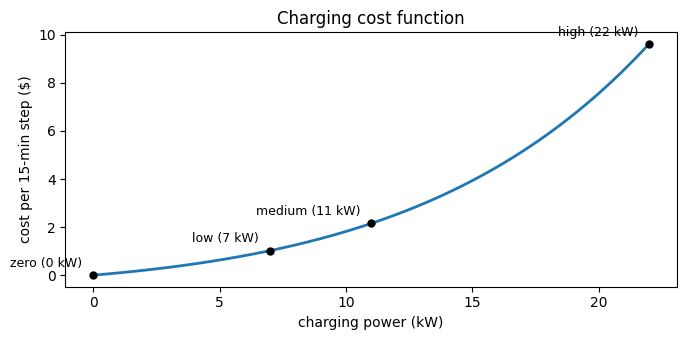

In [5]:
#| label: fig-rl-cost
#| fig-cap: "Charging cost as a exponential function of charging power"

# # # Cost function plot # # #
powers = np.linspace(0, P_MAX, 100)
costs = [charging_cost(p) for p in powers]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(powers, costs, lw=2)
for name, p in CHARGING_LEVELS.items():
    ax.plot(p, charging_cost(p), "o", color="black", ms=5)
    ax.annotate(f"{name} ({p} kW)", (p, charging_cost(p)), xytext=(-8, 6),
                textcoords="offset points", ha="right", fontsize=9)
ax.set_xlabel("charging power (kW)")
ax.set_ylabel("cost per 15-min step ($)")
ax.set_title("Charging cost function")
fig.tight_layout()
plt.show()

## 3. Gymnasium environment

`reset` draws a random start SOC and a fresh demand $D \sim \mathcal{N}(\mu, \sigma)$; the
departure penalty is checked against that realized demand.

In [ ]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Gymnasium environment                   #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

class EVChargingEnv(gym.Env):

    def __init__(self):
        super().__init__()
        self.action_space = spaces.Discrete(len(POWERS))
        self.observation_space = spaces.MultiDiscrete([int(CAPACITY * 4) + 1, N_STEPS])

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)  
        self.soc = round(self.np_random.uniform(SOC_INIT_MIN, SOC_INIT_MAX) * 4) / 4
        self.t = 0
        self.demand = min(max(0.0, self.np_random.normal(DEMAND_MU, DEMAND_SIGMA)), CAPACITY)  # drawn once, hidden
        return self._state(), {}

    def _state(self):
        # integer SOC index (SOC is always a multiple of 0.25) -> a valid MultiDiscrete sample
        return (int(round(self.soc * 4)), self.t)

    def step(self, action):
        power = POWERS[action]
        self.soc = min(self.soc + power * DELTA_T, CAPACITY)
        reward = -charging_cost(power)
        self.t += 1
        terminated = self.t >= N_STEPS
        if terminated and self.soc < self.demand:     # this day's demand not met
            reward -= PENALTY
        return self._state(), reward, terminated, False, {}


# Sanity check: one episode with random actions
env = EVChargingEnv()
state, _ = env.reset(seed=0)
start_soc = env.soc
done, total = False, 0.0
while not done:
    state, r, term, trunc, _ = env.step(env.action_space.sample())
    total += r
    done = term or trunc
print(f"Random policy -> start SOC {start_soc:.2f}, final SOC {env.soc:.1f} kWh, demand {env.demand:.1f} kWh, reward {total:.1f}")

Random policy -> start SOC 11.25, final SOC 38.8 kWh, demand 29.3 kWh, reward -37.5


## 4. Optimal policy (expected-cost benchmark)

The MDP is small enough to solve exactly. The dynamics are deterministic and the random demand
only enters through the terminal reward, whose expectation is known in closed form:
$\text{PENALTY}\cdot\,(1-\Phi(\tfrac{\text{SOC}-\mu}{\sigma}))$. **Backward induction** (dynamic
programming) over the $(\text{SOC},\ t)$ grid therefore gives the exact $Q^*(s,a)$ and $V^*(s)$
for every state — this is also what the plots in section 7 compare the learned policies against.
Because the initial SOC is random, the optimum is a *policy*, not a single schedule — the
benchmark `best_cost` is the expected optimal cost **averaged over the initial-SOC distribution**,
i.e. the mean of $-V^*(\text{SOC},\ t{=}0)$ over the start-SOC grid.

In [7]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Optimal policy (dynamic programming)    #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# The best schedule depends on the SOC we start from, so the benchmark is the EXPECTED
# optimal cost, averaged over the initial-SOC distribution U(SOC_INIT_MIN, SOC_INIT_MAX).
SOC_EVAL_GRID = np.linspace(SOC_INIT_MIN, SOC_INIT_MAX, 21)   # grid over the random start SOC

SOC_GRID   = np.arange(int(CAPACITY * 4) + 1) / 4.0          # every state's SOC, 0.25 kWh apart
_STEP_COST = np.array([charging_cost(p) for p in POWERS])    # $ per action
_NEXT_IDX  = np.stack([np.rint(np.minimum(SOC_GRID + p * DELTA_T, CAPACITY) * 4).astype(int)
                       for p in POWERS], axis=1)             # (n_soc, n_actions) -> next SOC index
_TERM_COST = PENALTY * (1.0 - norm.cdf((SOC_GRID - DEMAND_MU) / DEMAND_SIGMA))   # expected penalty


def _soc_idx(soc):
    """SOC in kWh -> index on the 0.25 kWh state grid."""
    return int(round(soc * 4))


def solve_dp():
    """Exact Q*(s,a) and V*(s) for EVERY state by backward induction (8 x 241 x 4 - instant)."""
    Qs = np.zeros((N_STEPS, len(SOC_GRID), len(POWERS)))
    V  = np.zeros((N_STEPS + 1, len(SOC_GRID)))
    V[N_STEPS] = -_TERM_COST                                 # departure: only the expected penalty
    for t in range(N_STEPS - 1, -1, -1):
        Qs[t] = -_STEP_COST + V[t + 1][_NEXT_IDX]            # cost now + value of where we land
        V[t]  = Qs[t].max(axis=1)
    return Qs, V


Q_STAR, V_STAR = solve_dp()
PI_STAR = Q_STAR.argmax(axis=2)                              # (N_STEPS, n_soc) optimal action id


def optimal_schedule(soc_init):
    """Optimal schedule from a given start SOC (follow pi*), its expected cost and final SOC."""
    idx, seq = _soc_idx(soc_init), []
    for t in range(N_STEPS):
        a = int(PI_STAR[t, idx])
        seq.append(a)
        idx = int(_NEXT_IDX[idx, a])
    return np.array(seq), float(-V_STAR[0, _soc_idx(soc_init)]), float(SOC_GRID[idx])


# The yardstick: expected optimal cost averaged over the initial-SOC distribution
best_cost = float(np.mean([-V_STAR[0, _soc_idx(s0)] for s0 in SOC_EVAL_GRID]))
print(f"Optimal EXPECTED cost, averaged over start SOC in "
      f"[{SOC_INIT_MIN:.0f}, {SOC_INIT_MAX:.0f}] kWh: {best_cost:.2f}\n")

print("The optimum depends on where we start:")
for s0 in (SOC_INIT_MIN, 0.5 * (SOC_INIT_MIN + SOC_INIT_MAX), SOC_INIT_MAX):
    seq, cost, soc = optimal_schedule(s0)
    print(f"  start SOC {s0:4.1f} -> cost {cost:5.2f}, final SOC {soc:5.2f}: {[ACTIONS[a] for a in seq]}")

Optimal EXPECTED cost, averaged over start SOC in [5, 15] kWh: 39.10

The optimum depends on where we start:
  start SOC  5.0 -> cost 52.59, final SOC 38.00: ['medium', 'medium', 'medium', 'medium', 'high', 'high', 'high', 'high']
  start SOC 10.0 -> cost 38.84, final SOC 37.50: ['medium', 'medium', 'medium', 'medium', 'medium', 'medium', 'high', 'high']
  start SOC 15.0 -> cost 25.29, final SOC 37.00: ['medium', 'medium', 'medium', 'medium', 'medium', 'medium', 'medium', 'medium']


In [ ]:
# # # Shared helpers (used by both learning methods) # # #
SOC_SHOWCASE = (SOC_INIT_MIN, 0.5 * (SOC_INIT_MIN + SOC_INIT_MAX), SOC_INIT_MAX)   # 5 / 10 / 15 kWh


def epsilon_greedy(Q, state, eps, n_actions):
    if np.random.rand() < eps:
        return np.random.randint(n_actions)   # explore: random action
    return int(np.argmax(Q[state]))           # exploit: current best action


def expected_cost(final_soc, charge):
    return charge + PENALTY * (1.0 - norm.cdf((final_soc - DEMAND_MU) / DEMAND_SIGMA))


def _greedy_actions_from(env, Q, soc_init):
    env.reset()
    env.soc, env.t = float(soc_init), 0
    actions, charge = [], 0.0
    while env.t < N_STEPS:
        a = int(np.argmax(Q[env._state()]))
        actions.append(a)
        charge += charging_cost(POWERS[a])
        env.step(a)
    return actions, env.soc, charge


def greedy_cost(env, Q):
    return float(np.mean([expected_cost(*_greedy_actions_from(env, Q, s0)[1:]) for s0 in SOC_EVAL_GRID]))


def _fmt_schedule(actions):
    return " ".join(f"{ACTIONS[a]:>6s}" for a in actions)


def greedy_rollout(env, Q, label):
    print(f"{label} - greedy schedule vs optimum, per start SOC:\n")
    for s0 in SOC_SHOWCASE:
        acts, final_soc, charge = _greedy_actions_from(env, Q, s0)
        cost      = expected_cost(final_soc, charge)
        p_short   = 1.0 - norm.cdf((final_soc - DEMAND_MU) / DEMAND_SIGMA)
        opt_seq, opt_cost, opt_soc = optimal_schedule(s0)
        opt_short = 1.0 - norm.cdf((opt_soc - DEMAND_MU) / DEMAND_SIGMA)
        print(f"  start SOC {s0:4.1f} kWh")
        print(f"    learned  cost {cost:6.2f}  final SOC {final_soc:5.2f}  "
              f"P(short) {p_short:5.1%}  {_fmt_schedule(acts)}")
        print(f"    optimal  cost {opt_cost:6.2f}  final SOC {opt_soc:5.2f}  "
              f"P(short) {opt_short:5.1%}  {_fmt_schedule(opt_seq)}")
        print(f"    gap      {cost - opt_cost:+6.2f}\n")
    avg = greedy_cost(env, Q)                                 # averaged over the start-SOC range
    print(f"  expected cost averaged over start SOC: {avg:.2f}   vs optimum {best_cost:.2f}"
          f"   (gap {avg - best_cost:+.2f})")
    return avg


def plot_learning_curve(curve, title, eval_every):
    x = np.arange(len(curve)) * eval_every
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, curve, label="greedy-policy expected cost")
    ax.axhline(best_cost, ls="--", color="green", label=f"optimum ({best_cost:.1f})")
    ax.set_yscale("log")
    ax.set_xlabel("episode")
    ax.set_ylabel("expected cost of greedy policy ($, log scale)")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.show()

## 5. Monte Carlo

First-visit Monte Carlo control with a fixed exploration rate $\varepsilon$: play a full episode,
then update $Q(s,a)$ towards the observed return by a running average. The randomly-sampled
penalty simply gets averaged over many episodes.

In [9]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Monte Carlo                             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def train_mc(env, n_episodes=80000, gamma=1.0, epsilon=0.3, eval_every=400):
    n_actions = env.action_space.n
    Q      = defaultdict(lambda: np.zeros(n_actions))   # action-value estimates
    counts = defaultdict(lambda: np.zeros(n_actions))   # visit counts (average + diagnostics)
    curve  = []                                          # greedy-policy expected cost during training

    for ep in range(n_episodes):
        # 1) play one episode (demand is sampled inside env.reset)
        state, _ = env.reset()
        episode, done = [], False
        while not done:
            a = epsilon_greedy(Q, state, epsilon, n_actions)
            nxt, r, term, trunc, _ = env.step(a)
            episode.append((state, a, r))
            state, done = nxt, term or trunc

        # 2) update Q towards the return G (running average)
        G = 0.0
        for state, a, r in reversed(episode):
            G = r + gamma * G
            counts[state][a] += 1
            Q[state][a] += (G - Q[state][a]) / counts[state][a]

        if ep % eval_every == 0:
            curve.append(greedy_cost(env, Q))
    return Q, curve, counts


Q_mc, curve_mc, counts_mc = train_mc(env, epsilon=0.3)
print(f"Training done. Visited {len(Q_mc)} states.")

Training done. Visited 889 states.


Monte Carlo - greedy schedule vs optimum, per start SOC:

  start SOC  5.0 kWh
    learned  cost  52.59  final SOC 38.00  P(short)  5.5%    high   high medium   high   high medium medium medium
    optimal  cost  52.59  final SOC 38.00  P(short)  5.5%  medium medium medium medium   high   high   high   high
    gap       +0.00

  start SOC 10.0 kWh
    learned  cost  41.72  final SOC 39.25  P(short)  3.2%    high medium medium   high medium    low medium   high
    optimal  cost  38.84  final SOC 37.50  P(short)  6.7%  medium medium medium medium medium medium   high   high
    gap       +2.88

  start SOC 15.0 kWh
    learned  cost  32.89  final SOC 38.75  P(short)  4.0%    high   zero    low medium   high medium medium medium
    optimal  cost  25.29  final SOC 37.00  P(short)  8.1%  medium medium medium medium medium medium medium medium
    gap       +7.59

  expected cost averaged over start SOC: 41.03   vs optimum 39.10   (gap +1.94)


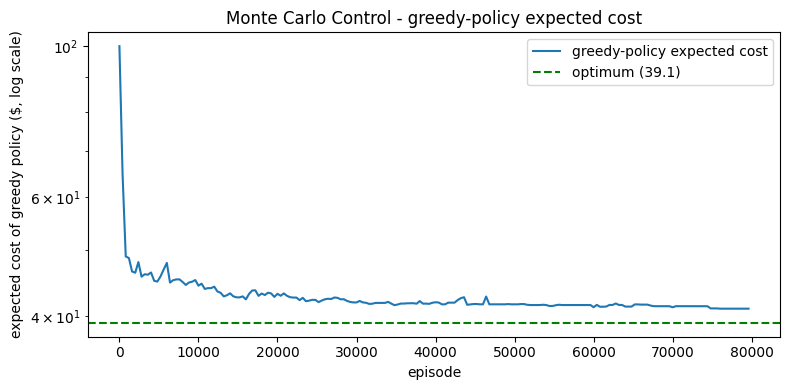

In [10]:
# # # Monte Carlo - results # # #
mc_cost = greedy_rollout(env, Q_mc, "Monte Carlo")
plot_learning_curve(curve_mc, "Monte Carlo Control - greedy-policy expected cost", eval_every=400)

## 6. Q-learning

The off-policy TD update with a constant step size $\alpha$:

$$Q(s,a) \;\leftarrow\; Q(s,a) + \alpha\,\big[\,r + \gamma\,\max_{a'} Q(s',a') - Q(s,a)\,\big]$$

Unlike Monte Carlo it bootstraps from $\max_{a'} Q(s',a')$, so updates propagate the (rare, large)
departure penalty backwards through the value estimates step by step.

In [11]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Q-Learning                              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def train_qlearning(env, n_episodes=80000, gamma=1.0, epsilon=0.3, eval_every=400, alpha=0.1):
    n_actions = env.action_space.n
    Q      = defaultdict(lambda: np.zeros(n_actions))
    counts = defaultdict(lambda: np.zeros(n_actions))   # visit counts (diagnostics only)
    curve  = []

    for ep in range(n_episodes):
        state, _ = env.reset()
        done = False
        while not done:
            a = epsilon_greedy(Q, state, epsilon, n_actions)
            counts[state][a] += 1
            nxt, r, term, trunc, _ = env.step(a)
            done = term or trunc
            best_next = 0.0 if done else np.max(Q[nxt])   # bootstrap from the greedy action
            td_target = r + gamma * best_next             # partly a GUESS: it contains max Q[s']
            Q[state][a] += alpha * (td_target - Q[state][a])
            state = nxt

        if ep % eval_every == 0:
            curve.append(greedy_cost(env, Q))
    return Q, curve, counts


Q_ql, curve_ql, counts_ql = train_qlearning(env, epsilon=0.3)
print(f"Training done. Visited {len(Q_ql)} states.")

Training done. Visited 903 states.


Q-learning - greedy schedule vs optimum, per start SOC:

  start SOC  5.0 kWh
    learned  cost  56.16  final SOC 40.75  P(short)  1.6%  medium medium   high   high medium   high   high   high
    optimal  cost  52.59  final SOC 38.00  P(short)  5.5%  medium medium medium medium   high   high   high   high
    gap       +3.57

  start SOC 10.0 kWh
    learned  cost  40.71  final SOC 36.50  P(short)  9.7%  medium   high medium   high medium medium    low medium
    optimal  cost  38.84  final SOC 37.50  P(short)  6.7%  medium medium medium medium medium medium   high   high
    gap       +1.87

  start SOC 15.0 kWh
    learned  cost  28.49  final SOC 37.75  P(short)  6.1%  medium medium medium medium    low medium    low   high
    optimal  cost  25.29  final SOC 37.00  P(short)  8.1%  medium medium medium medium medium medium medium medium
    gap       +3.19

  expected cost averaged over start SOC: 41.06   vs optimum 39.10   (gap +1.96)


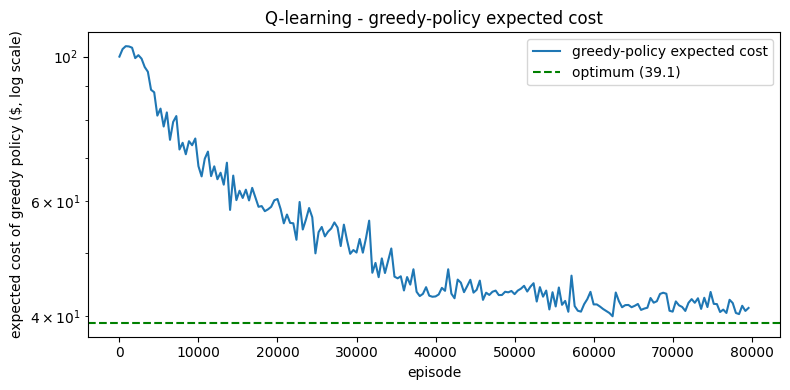

In [12]:
# # # Q-learning - results # # #
ql_cost = greedy_rollout(env, Q_ql, "Q-learning")
plot_learning_curve(curve_ql, "Q-learning - greedy-policy expected cost", eval_every=400)

### Learning curves compared

Both methods are evaluated identically during training (the greedy policy's expected cost every
400 episodes), so their curves share one axis — this makes the convergence speed and the
remaining gap to the optimum directly comparable.

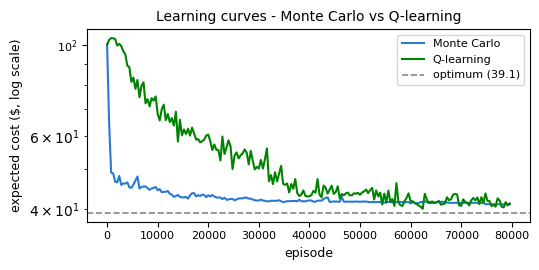

In [13]:
#| label: fig-rl-curves
#| fig-cap: "Learning curves of Monte Carlo and Q-learning"

# # # Learning curves - MC vs Q-learning # # #
EVAL_EVERY = 400
fig, ax = plt.subplots(figsize=(5.5, 2.8))
ax.plot(np.arange(len(curve_mc)) * EVAL_EVERY, curve_mc, color="#2a78d6", lw=1.5, label="Monte Carlo")
ax.plot(np.arange(len(curve_ql)) * EVAL_EVERY, curve_ql, color="#008300", lw=1.5, label="Q-learning")
ax.axhline(best_cost, ls="--", color="#898781", lw=1.2, label=f"optimum ({best_cost:.1f})")
ax.set_yscale("log")
ax.set_xlabel("episode", fontsize=9)
ax.set_ylabel("expected cost ($, log scale)", fontsize=9)
ax.set_title("Learning curves - Monte Carlo vs Q-learning", fontsize=10)
ax.tick_params(labelsize=8)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 7. Visualising the learned policies

Printed schedules only show 3 of ~900 states, so we compare the whole tables over the
$(\text{SOC},\ t)$ grid

**Policies** — the exact $\pi^*$ from section 4 next to both learned greedy policies, with the
  greedy trajectories from start SOC 5 / 10 / 15 on top. The learned panels look patchier than
  $\pi^*$ even where data is plentiful, and that is often fine: the total cost depends only on
  *how many* steps of each power a schedule uses, not their order, so several actions are
  frequently **exactly co-optimal** and the learned argmax flips between them.


In [14]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualising the learned policies        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import matplotlib.patheffects as pe
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

SURFACE, INK, MUTED, UNTRAINED = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9"
ACTION_CMAP = ListedColormap(["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])   # ordinal: zero -> high
ACTION_NORM = BoundaryNorm(np.arange(len(POWERS) + 1) - 0.5, len(POWERS))
MIN_VISITS  = 25                                 # below this, a Q row is noise, not knowledge
EXTENT      = [-0.5, N_STEPS - 0.5, -0.125, CAPACITY + 0.125]


def _dense_policy(Q):
    """Greedy action per state; empty rows -> action 0 (exactly how the env would act).

    Careful: querying a defaultdict INSERTS the key, so evaluation (greedy_cost / greedy_rollout)
    silently adds all-zero rows - `len(Q)` overstates how much was actually learned. The visit
    counts, not Q itself, say where the agent has data.
    """
    vals = np.zeros((N_STEPS, len(SOC_GRID), len(POWERS)))
    for (i, t), q in Q.items():
        if t < N_STEPS:
            vals[t, i] = q
    return vals.argmax(axis=2)


def _dense_visits(counts):
    v = np.zeros((N_STEPS, len(SOC_GRID)))
    for (i, t), c in counts.items():
        if t < N_STEPS:
            v[t, i] = c.sum()
    return v


def _style(ax, ylabel=False):
    ax.axhline(DEMAND_MU, color=MUTED, ls="--", lw=1.5, zorder=2)
    ax.set_xlim(-0.5, N_STEPS - 0.5)
    ax.set_ylim(SOC_INIT_MIN - 1, 46)
    ax.set_xticks(range(N_STEPS))
    ax.set_xlabel("time step $t$")
    ax.tick_params(colors=MUTED)
    for spine in ax.spines.values():
        spine.set_color(MUTED)
    if ylabel:
        ax.set_ylabel("SOC (kWh)")


def _draw_path(ax, actions, s0, annotate):
    path = [s0]
    for a in actions:
        path.append(min(path[-1] + POWERS[a] * DELTA_T, CAPACITY))
    ax.plot(range(N_STEPS + 1), path, color=INK, lw=2, marker="o", ms=5,
            mec=SURFACE, mew=1.5, zorder=3)
    if annotate:
        ax.annotate(f"start {s0:.0f}", (0, s0), xytext=(5, 7), textcoords="offset points",
                    ha="left", fontsize=9, color=INK, zorder=4,
                    path_effects=[pe.withStroke(linewidth=3, foreground=SURFACE)])


def plot_policies(methods):
    """pi* next to the learned greedy policies; states with too few visits are grey."""
    fig, axes = plt.subplots(1, 1 + len(methods), figsize=(16, 5.4), sharey=True)

    axes[0].imshow(PI_STAR.T, origin="lower", aspect="auto", extent=EXTENT,
                   cmap=ACTION_CMAP, norm=ACTION_NORM, interpolation="nearest")
    axes[0].set_title("Optimal policy $\\pi^*$  (exact, by DP)", fontsize=11, color=INK)
    for s0 in SOC_SHOWCASE:
        _draw_path(axes[0], optimal_schedule(s0)[0], s0, annotate=True)

    for ax, (label, Q, counts) in zip(axes[1:], methods):
        pi, visits = _dense_policy(Q), _dense_visits(counts)
        ax.imshow(np.ma.masked_where(visits.T < MIN_VISITS, pi.T), origin="lower", aspect="auto",
                  extent=EXTENT, cmap=ACTION_CMAP, norm=ACTION_NORM, interpolation="nearest")
        ax.set_facecolor(UNTRAINED)                       # low-data states show through as grey
        ax.set_title(f"{label}: learned greedy policy", fontsize=11, color=INK)
        for s0 in SOC_SHOWCASE:
            _draw_path(ax, _greedy_actions_from(env, Q, s0)[0], s0, annotate=False)

    for i, ax in enumerate(axes):
        _style(ax, ylabel=(i == 0))
    axes[0].annotate("mean demand", (-0.4, DEMAND_MU), xytext=(0, 4),
                     textcoords="offset points", fontsize=9, color=MUTED)

    handles = [Patch(facecolor=ACTION_CMAP(i), label=f"{ACTIONS[i]} ({POWERS[i]} kW)")
               for i in range(len(POWERS))]
    handles.append(Patch(facecolor=UNTRAINED, label=f"< {MIN_VISITS} training visits"))
    fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False, fontsize=9)
    fig.suptitle("Optimal vs learned greedy policies (trajectories from start SOC 5 / 10 / 15)",
                 fontsize=13, fontweight="bold")
    fig.tight_layout(rect=[0, 0.06, 1, 0.94])
    plt.show()

LEARNED = [("Monte Carlo", Q_mc, counts_mc), ("Q-learning", Q_ql, counts_ql)]

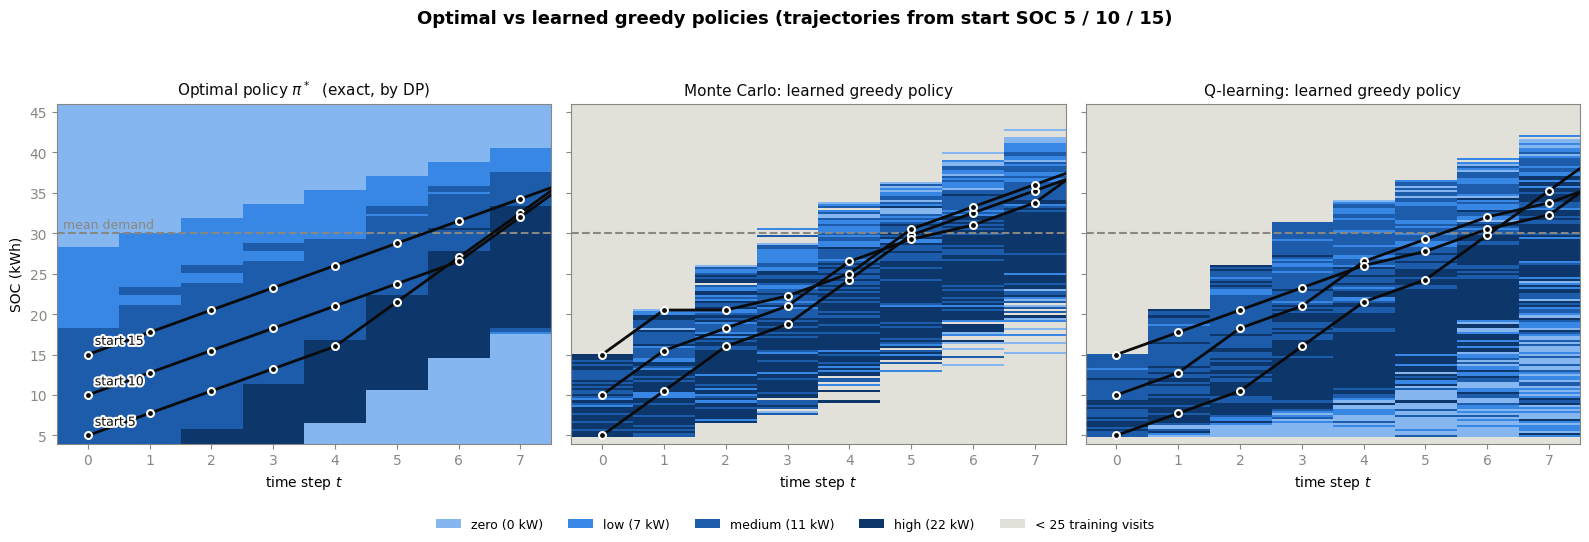

In [15]:
#| label: fig-rl-policies
#| fig-cap: "The exact optimal policy next to policies learned by Monte Carlo and Q-learning"
plot_policies(LEARNED)